In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Part 4

In [8]:
# Symbols
lam = sp.symbols('lambda')
I, Gamma, k, T = sp.symbols('I Gamma k T', positive=True)
mu, kappa, r3 = sp.symbols('mu kappa r3', positive=True)

# Linearized A matrix
A = sp.Matrix([
    [0, 1, 0, 0],
    [-k/(I*T**2), 0, 1/(I*T), 0],
    [0, 0, 0, 1],
    [0, -mu*kappa*r3**2, -kappa*r3**2, -r3*(1+kappa)]
])

# Characteristic equation det(A - lambda*I) = 0
char_poly = sp.factor((A - lam*sp.eye(4)).det())
sp.simplify(char_poly)
char_poly

(I*T**2*kappa*lambda**3*r3 + I*T**2*kappa*lambda**2*r3**2 + I*T**2*lambda**4 + I*T**2*lambda**3*r3 + T*kappa*lambda*mu*r3**2 + k*kappa*lambda*r3 + k*kappa*r3**2 + k*lambda**2 + k*lambda*r3)/(I*T**2)

# Part 5


In [10]:
omega = sp.symbols('omega', real=True)

# Use positive-leading characteristic equation
poly = (
    I*T**2*lam**4
    + I*T**2*r3*(1+kappa)*lam**3
    + (I*T**2*kappa*r3**2 + k)*lam**2
    + (k*r3*(1+kappa) + T*mu*kappa*r3**2)*lam
    + k*kappa*r3**2
)

# Substitute lambda = i omega
poly_iw = sp.expand(poly.subs(lam, sp.I*omega))

real_eq = sp.simplify(sp.re(poly_iw))
imag_eq = sp.simplify(sp.im(poly_iw))

real_eq

-I*T**2*kappa*omega**2*r3**2 + I*T**2*omega**4 + k*kappa*r3**2 - k*omega**2

In [11]:
imag_eq

omega*r3*(-I*T**2*kappa*omega**2 - I*T**2*omega**2 + T*kappa*mu*r3 + k*kappa + k)

# Part 6

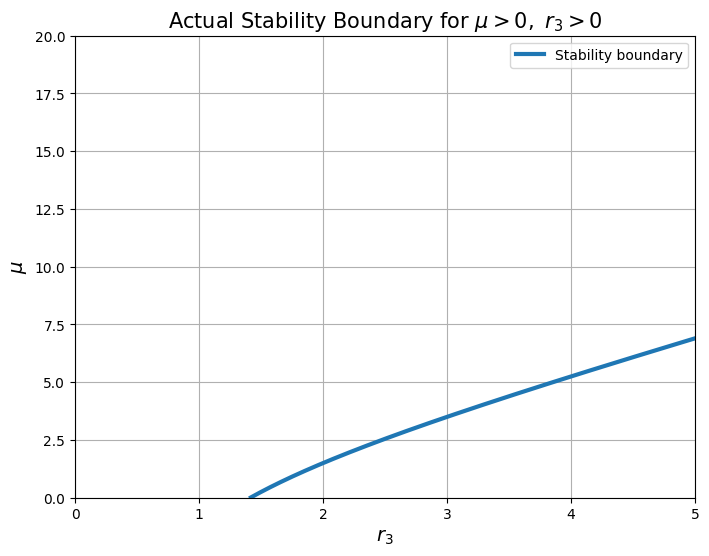

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed parameters
I_val = 1.0
T_val = 1.0
k_val = 1.0
kappa_val = 0.5

r3_vals = np.linspace(0.01, 5.0, 1000)

# Actual nontrivial boundary:
# mu = (1+kappa)(I*T^2*kappa*r3^2 - k)/(T*kappa*r3)

mu_boundary = (
    (1 + kappa_val)
    * (I_val*T_val**2*kappa_val*r3_vals**2 - k_val)
    / (T_val*kappa_val*r3_vals)
)

# Keep only mu > 0
mask = mu_boundary > 0

plt.figure(figsize=(8,6))

plt.plot(
    r3_vals[mask],
    mu_boundary[mask],
    linewidth=3,
    label="Stability boundary"
)

plt.xlabel(r"$r_3$", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)
plt.title(r"Actual Stability Boundary for $\mu>0,\ r_3>0$", fontsize=15)

plt.xlim(0, 5)
plt.ylim(0, 20)

plt.grid(True)
plt.legend()
plt.show()

# Part 7

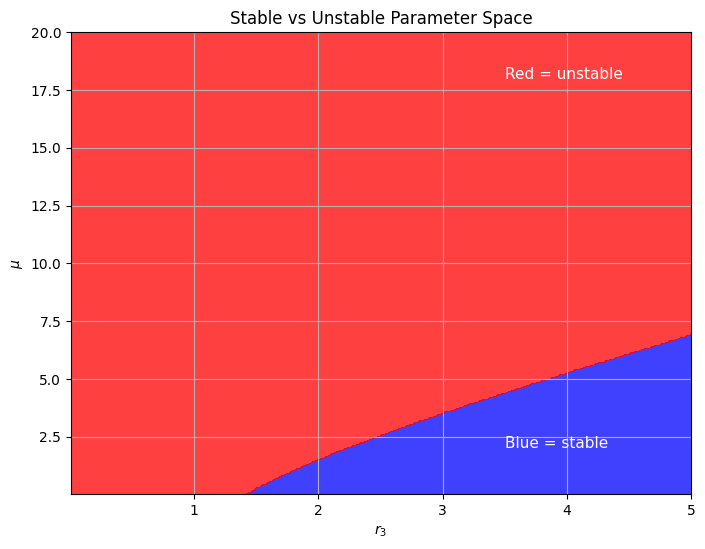

In [14]:
# Parameter grid
r3_vals = np.linspace(0.01, 5.0, 300)
mu_vals = np.linspace(0.01, 20.0, 300)

stability = np.zeros((len(mu_vals), len(r3_vals)))

for i, mu_val in enumerate(mu_vals):
    for j, r3_val in enumerate(r3_vals):

        A_num = np.array([
            [0, 1, 0, 0],
            [-k_val/(I_val*T_val**2), 0, 1/(I_val*T_val), 0],
            [0, 0, 0, 1],
            [0, -mu_val*kappa_val*r3_val**2,
             -kappa_val*r3_val**2,
             -r3_val*(1+kappa_val)]
        ], dtype=float)

        eigvals = np.linalg.eigvals(A_num)

        # Red if at least one eigenvalue has positive real part
        if np.any(np.real(eigvals) > 0):
            stability[i, j] = 1
        else:
            stability[i, j] = 0

plt.figure(figsize=(8, 6))

plt.contourf(
    r3_vals,
    mu_vals,
    stability,
    levels=[-0.5, 0.5, 1.5],
    colors=["blue", "red"],
    alpha=0.75
)

plt.xlabel(r"$r_3$")
plt.ylabel(r"$\mu$")
plt.title("Stable vs Unstable Parameter Space")
plt.grid(True)

plt.text(3.5, 2, "Blue = stable", color="white", fontsize=11)
plt.text(3.5, 18, "Red = unstable", color="white", fontsize=11)

plt.show()